## module 1: baseline classifier
plain resnet50 fine-tune - no bells and whistles. **kept as a fixed baseline**; the improved model lives in 04. do not add upgrades here, it is the comparison point.

> **how to work here: this notebook is run-only.** execute it top-to-bottom to (re)produce the baseline checkpoint, then leave it alone. **all model experiments go in `04_train_improved`** — 03 stays fixed so 04 has an honest thing to beat. training here writes a `.pt` to `../checkpoints/`; it does **not** touch the MLflow registry or the app on its own — you register + promote it afterward (`mlops/`, see the README).

runs **locally or on colab** (auto-detected): uses local `../data` if present, else pulls the dataset from hugging face. resumable - saves full state every `CKPT_EVERY` steps and continues from the last checkpoint, so a long run or a colab disconnect picks up where it left off.

In [1]:
import os, json, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from tqdm.auto import tqdm

In [2]:
# environment: local files if present (maintainer), else hugging face (colab / teammates)
try:
    import google.colab  # noqa
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

USE_LOCAL = Path("../data/splits.csv").exists()
HF_REPO = "dbabnigg/botanical-vision-256"  # downscaled, Colab-friendly build
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| data:", "local" if USE_LOCAL else "huggingface", "| colab:", ON_COLAB)

device: cuda | data: local | colab: False


In [3]:
# subset toggle: set N_SPECIES to an int (e.g. 100) for a quick proof-of-concept run, None for all
N_SPECIES = None

if USE_LOCAL:
    splits = pd.read_csv("../data/splits.csv")
    if N_SPECIES:
        keep = sorted(splits["species"].unique())[:N_SPECIES]
        splits = splits[splits["species"].isin(keep)].reset_index(drop=True)
    labels = sorted(splits["species"].unique())
    counts = splits["split"].value_counts()
else:
    from datasets import load_dataset
    hf = load_dataset(HF_REPO)
    if N_SPECIES:
        keep = set(sorted(hf["train"].features["label"].names)[:N_SPECIES])
        hf = hf.filter(lambda e: e["species"] in keep)
        labels = sorted(set(hf["train"]["species"]))
    else:
        labels = sorted(hf["train"].features["label"].names)
    counts = {k: len(hf[k]) for k in hf}

label2idx = {s:i for i,s in enumerate(labels)}
print(len(labels), "species")
print(counts)

4094 species
split
train    285136
test      61335
val       61288
Name: count, dtype: int64


In [4]:
# imagenet normalization, light aug on train
MEAN = [0.485,0.456,0.406]
STD = [0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224,scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

In [5]:
# datasets read from local files or from the in-memory HF dataset, transparently
class PlantSetLocal(Dataset):
    def __init__(self, df, tf): self.df=df.reset_index(drop=True); self.tf=tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        return self.tf(Image.open(r["path"]).convert("RGB")), label2idx[r["species"]]

class PlantSetHF(Dataset):
    def __init__(self, ds, tf): self.ds=ds; self.tf=tf
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        ex = self.ds[i]
        return self.tf(ex["image"].convert("RGB")), label2idx[ex["species"]]

def make_ds(split, tf):
    if USE_LOCAL:
        return PlantSetLocal(splits[splits["split"]==split], tf)
    return PlantSetHF(hf[split], tf)

train_ds = make_ds("train", train_tf)
val_ds = make_ds("val", eval_tf)
test_ds = make_ds("test", eval_tf)

# batch/workers sized to the hardware: big batch on a 16GB T4, small on a 4GB laptop
if device.type == "cuda":
    VRAM = torch.cuda.get_device_properties(0).total_memory/1e9
    BATCH = 64 if VRAM > 8 else 16
else:
    BATCH = 16
NUM_WORKERS = 0 if os.name == "nt" else 2   # windows spawn issues -> 0; linux/colab -> parallel
USE_AMP = device.type == "cuda"             # mixed precision: big speedup on tensor-core GPUs (T4)

val_dl = DataLoader(val_ds,batch_size=BATCH,shuffle=False,num_workers=NUM_WORKERS)
test_dl = DataLoader(test_ds,batch_size=BATCH,shuffle=False,num_workers=NUM_WORKERS)
print(f"BATCH {BATCH} | workers {NUM_WORKERS} | amp {USE_AMP}")
len(train_ds), len(val_ds), len(test_ds)

BATCH 16 | workers 0 | amp True


(285136, 61288, 61335)

In [6]:
EPOCHS = 5

# resnet50 pretrained, swap the head for our classes
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(labels))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler(enabled=USE_AMP)

In [7]:
def run_epoch(dl, desc):
    # eval only (no grad); training is inline in the loop below so it can checkpoint
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad(), torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
        for x,y in tqdm(dl, desc=desc, leave=False):
            x,y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out,y).item()*len(y)
            correct += (out.argmax(1)==y).sum().item()
            n += len(y)
    return total_loss/n, correct/n

In [8]:
# --- checkpointing ---
CKPT_EVERY = 1000    # save every N optimizer steps (lower = safer, more IO)
RUN_NAME = "resnet50_baseline"
FRESH = False        # True = ignore any existing checkpoint and start over
SEED = 42

# colab wipes local disk on disconnect -> checkpoint to mounted Drive so progress survives
if ON_COLAB:
    try:
        from google.colab import drive; drive.mount("/content/drive")
    except Exception:
        print("run the 'Colab: Mount Google Drive to Server' command, then rerun this cell")
    CKPT_DIR = "/content/drive/MyDrive/botanical-vision/checkpoints"
else:
    CKPT_DIR = "../checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
last_path = f"{CKPT_DIR}/{RUN_NAME}_last.pt"
best_path = f"{CKPT_DIR}/{RUN_NAME}_best.pt"

# signature: a run only resumes a checkpoint with the SAME setup (else it's a different experiment)
_cfg = {"model":"resnet50","n_species":N_SPECIES,"epochs":EPOCHS,"n_labels":len(labels),"batch":BATCH,
        "seed":SEED,"lrs":[g["lr"] for g in optimizer.param_groups],
        "wd":optimizer.param_groups[0].get("weight_decay",0),
        "label_smoothing":getattr(criterion,"label_smoothing",0.0),"aug":str(train_tf)}
sig = hashlib.md5(json.dumps(_cfg, sort_keys=True).encode()).hexdigest()[:10]

def save_ckpt(path, epoch, step, run=(0.0,0,0)):
    # (epoch, step) = the NEXT batch to run. atomic write survives a mid-save disconnect.
    payload = {"sig":sig, "epoch":epoch, "step":step, "run":list(run), "state_dict":model.state_dict(),
               "opt":optimizer.state_dict(), "scaler":scaler.state_dict(),
               "best_val":best_val, "hist":hist, "labels":labels}
    torch.save(payload, path+".tmp"); os.replace(path+".tmp", path)

# resume if a matching checkpoint exists, else start fresh
start_epoch, start_step, best_val = 0, 0, 0.0
resume_run = (0.0, 0, 0)
hist = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
if os.path.exists(last_path) and not FRESH:
    ck = torch.load(last_path, weights_only=False, map_location=device)
    if ck["sig"] == sig:
        model.load_state_dict(ck["state_dict"]); optimizer.load_state_dict(ck["opt"]); scaler.load_state_dict(ck["scaler"])
        start_epoch, start_step, best_val, hist = ck["epoch"], ck["step"], ck["best_val"], ck["hist"]
        resume_run = tuple(ck.get("run", (0.0, 0, 0)))
        print(f"resuming: epoch {start_epoch+1}, step {start_step}, best_val {best_val:.3f}")
    else:
        print("existing checkpoint has a different config -> starting fresh")
else:
    print("fresh run")

resuming: epoch 1, step 17000, best_val 0.000


In [9]:
for ep in range(start_epoch, EPOCHS):
    # deterministic per-epoch order so a mid-epoch resume continues exactly where it stopped
    g = torch.Generator().manual_seed(SEED + ep)
    perm = torch.randperm(len(train_ds), generator=g).tolist()
    skip = start_step if ep == start_epoch else 0
    train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=perm[skip*BATCH:], num_workers=NUM_WORKERS)
    nbatch = len(train_dl)

    model.train()
    tot, cor, seen = resume_run if (ep == start_epoch and skip > 0) else (0.0, 0, 0)
    bar = tqdm(train_dl, desc=f"epoch {ep+1}/{EPOCHS} train", leave=False)
    for i,(x,y) in enumerate(bar):
        step = skip + i
        x,y = x.to(device), y.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            out = model(x); loss = criterion(out,y)
        optimizer.zero_grad()
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        tot += loss.item()*len(y); cor += (out.argmax(1)==y).sum().item(); seen += len(y)
        bar.set_postfix(loss=f"{tot/seen:.3f}", acc=f"{cor/seen:.3f}")
        if (step+1) % CKPT_EVERY == 0 and i < nbatch-1:
            save_ckpt(last_path, ep, step+1, (tot, cor, seen))
    tl, ta = tot/max(seen,1), cor/max(seen,1)

    vl, va = run_epoch(val_dl, f"epoch {ep+1}/{EPOCHS} val")
    hist["train_loss"].append(tl); hist["val_loss"].append(vl)
    hist["train_acc"].append(ta); hist["val_acc"].append(va)
    if va > best_val:
        best_val = va
        save_ckpt(best_path, ep+1, 0)
    save_ckpt(last_path, ep+1, 0)   # epoch boundary: next run starts the following epoch
    start_step = 0
    print(f"epoch {ep+1}: train_loss {tl:.3f} acc {ta:.3f} | val_loss {vl:.3f} acc {va:.3f}")

print(f"best val acc: {best_val:.3f}")

epoch 1/5 train:   0%|          | 0/821 [00:00<?, ?it/s]

epoch 1/5 val:   0%|          | 0/3831 [00:00<?, ?it/s]

epoch 1: train_loss 5.089 acc 0.180 | val_loss 3.232 acc 0.374


epoch 2/5 train:   0%|          | 0/17821 [00:00<?, ?it/s]

epoch 2/5 val:   0%|          | 0/3831 [00:00<?, ?it/s]

...

epoch 4/5 val:   0%|          | 0/3831 [00:00<?, ?it/s]

epoch 4: train_loss 1.644 acc 0.632 | val_loss 2.092 acc 0.569


epoch 5/5 train:   0%|          | 0/17821 [00:00<?, ?it/s]

epoch 5/5 val:   0%|          | 0/3831 [00:00<?, ?it/s]

epoch 5: train_loss 1.352 acc 0.688 | val_loss 1.999 acc 0.588
best val acc: 0.588


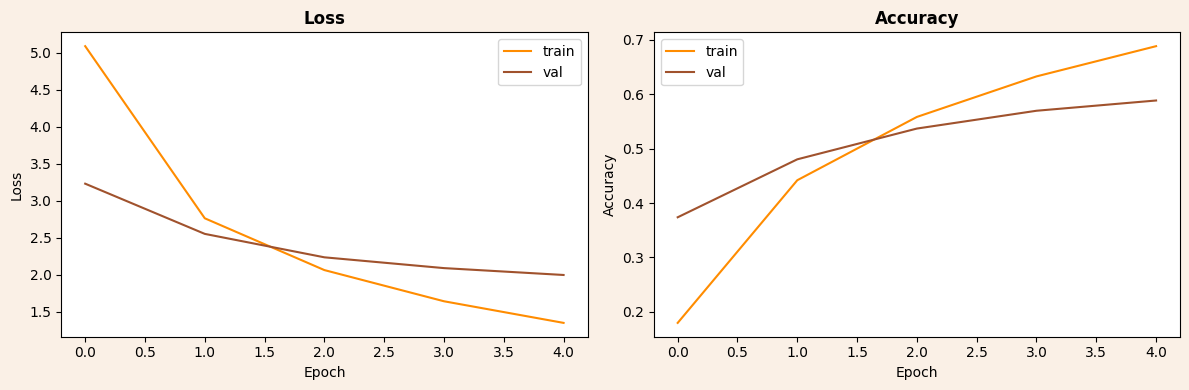

In [10]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
fig.set_facecolor("linen")

axs[0].plot(hist["train_loss"],color="darkorange",label="train")
axs[0].plot(hist["val_loss"],color="sienna",label="val")
axs[0].set_xlabel("Epoch"); axs[0].set_ylabel("Loss")
axs[0].set_title("Loss",weight="bold"); axs[0].legend()

axs[1].plot(hist["train_acc"],color="darkorange",label="train")
axs[1].plot(hist["val_acc"],color="sienna",label="val")
axs[1].set_xlabel("Epoch"); axs[1].set_ylabel("Accuracy")
axs[1].set_title("Accuracy",weight="bold"); axs[1].legend()
plt.tight_layout(); plt.show()

In [11]:
# top-1 / top-5 on test, using the best-val checkpoint
ck = torch.load(best_path, weights_only=False, map_location=device)
model.load_state_dict(ck["state_dict"]); model.eval()

top1, top5, n = 0, 0, 0
with torch.no_grad(), torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
    for x,y in tqdm(test_dl, desc="test"):
        x,y = x.to(device), y.to(device)
        out = model(x)
        top5_pred = out.topk(5,dim=1).indices
        top1 += (out.argmax(1)==y).sum().item()
        top5 += (top5_pred==y.unsqueeze(1)).any(1).sum().item()
        n += len(y)

print(f"test top-1: {top1/n:.3f}")
print(f"test top-5: {top5/n:.3f}")

test:   0%|          | 0/3834 [00:00<?, ?it/s]

test top-1: 0.581
test top-5: 0.782
